In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/Default_Fin.csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :    Index  Employed  Bank Balance  Annual Salary  Defaulted?
0      1         1       8754.36      532339.56           0
1      2         0       9806.16      145273.56           0
2      3         1      12882.60      381205.68           0
3      4         1       6351.00      428453.88           0
4      5         1       9427.92      461562.00           0
 dataframe shape : (10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank Balance   10000 non-null  float64
 3   Annual Salary  10000 non-null  float64
 4   Defaulted?     10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB
 dataframe info : None


In [84]:
y = df['Defaulted?']
x = df.drop(['Defaulted?'], axis = 1)

imputer = SimpleImputer(strategy='most_frequent')
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))


In [85]:
y_train.value_counts()

,count
Defaulted?,
0,7736
1,264


In [87]:
smote = SMOTE(random_state=42)
x, y= smote.fit_resample(x, y)

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(12377, 4)
(3095, 4)
(12377,)
(3095,)


In [89]:
y.value_counts()

,count
Defaulted?,
0,7736
1,7736


Accuracy: 0.952827140549273
Precision: 0.9344159900062461
Recall: 0.9733246584255042
F1 Score: 0.9534735500318674


Text(0.5, 1.0, 'Confusion Matrix')

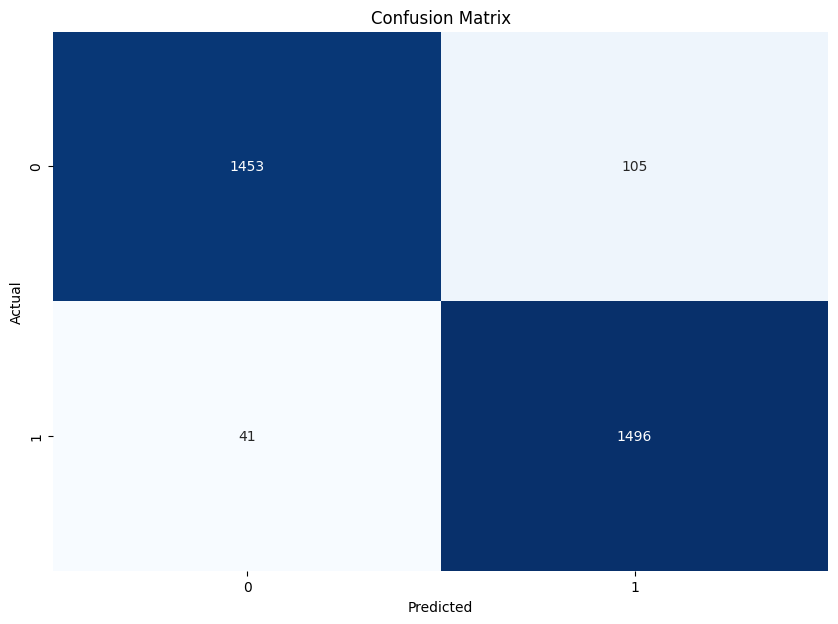

In [90]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost Regressor model
xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1)

# Train the model
xgb.fit(x_train, y_train)

# Make predictions on the test set
y_pred = xgb.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [91]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
